# Results Viz

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
base_df = pd.read_csv("wmt24pp_eval/wmt24pp_scores_baseline.csv")
int8_df = pd.read_csv("wmt24pp_eval/wmt24pp_scores_int8.csv")
int4_df = pd.read_csv("wmt24pp_eval/scores_int4_fixed.csv")

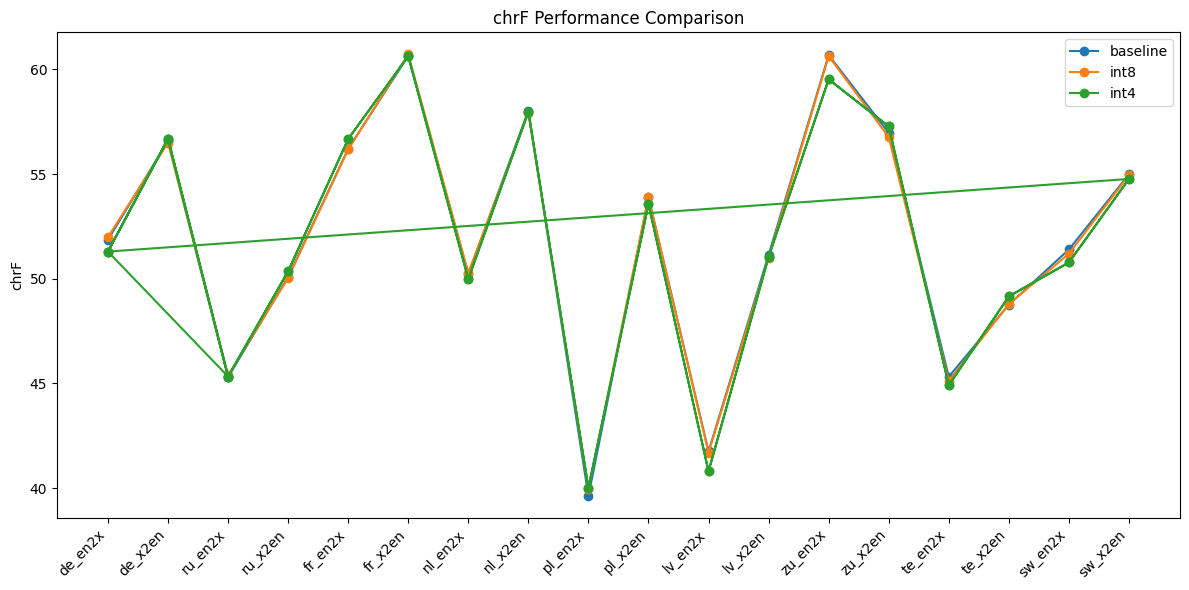

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Add labels so we know which system each df represents
base_df["system"] = "baseline"
int8_df["system"] = "int8"
int4_df["system"] = "int4"

# Combine all into a single dataframe
all_df = pd.concat([base_df, int8_df, int4_df], ignore_index=True)

# Plot chrF scores for each system grouped by lang+direction
plt.figure(figsize=(12, 6))
for sys in all_df["system"].unique():
    subset = all_df[all_df["system"] == sys]
    plt.plot(
        subset["lang"] + "_" + subset["direction"], 
        subset["chrf"], 
        marker="o", 
        label=sys
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("chrF")
plt.title("chrF Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()


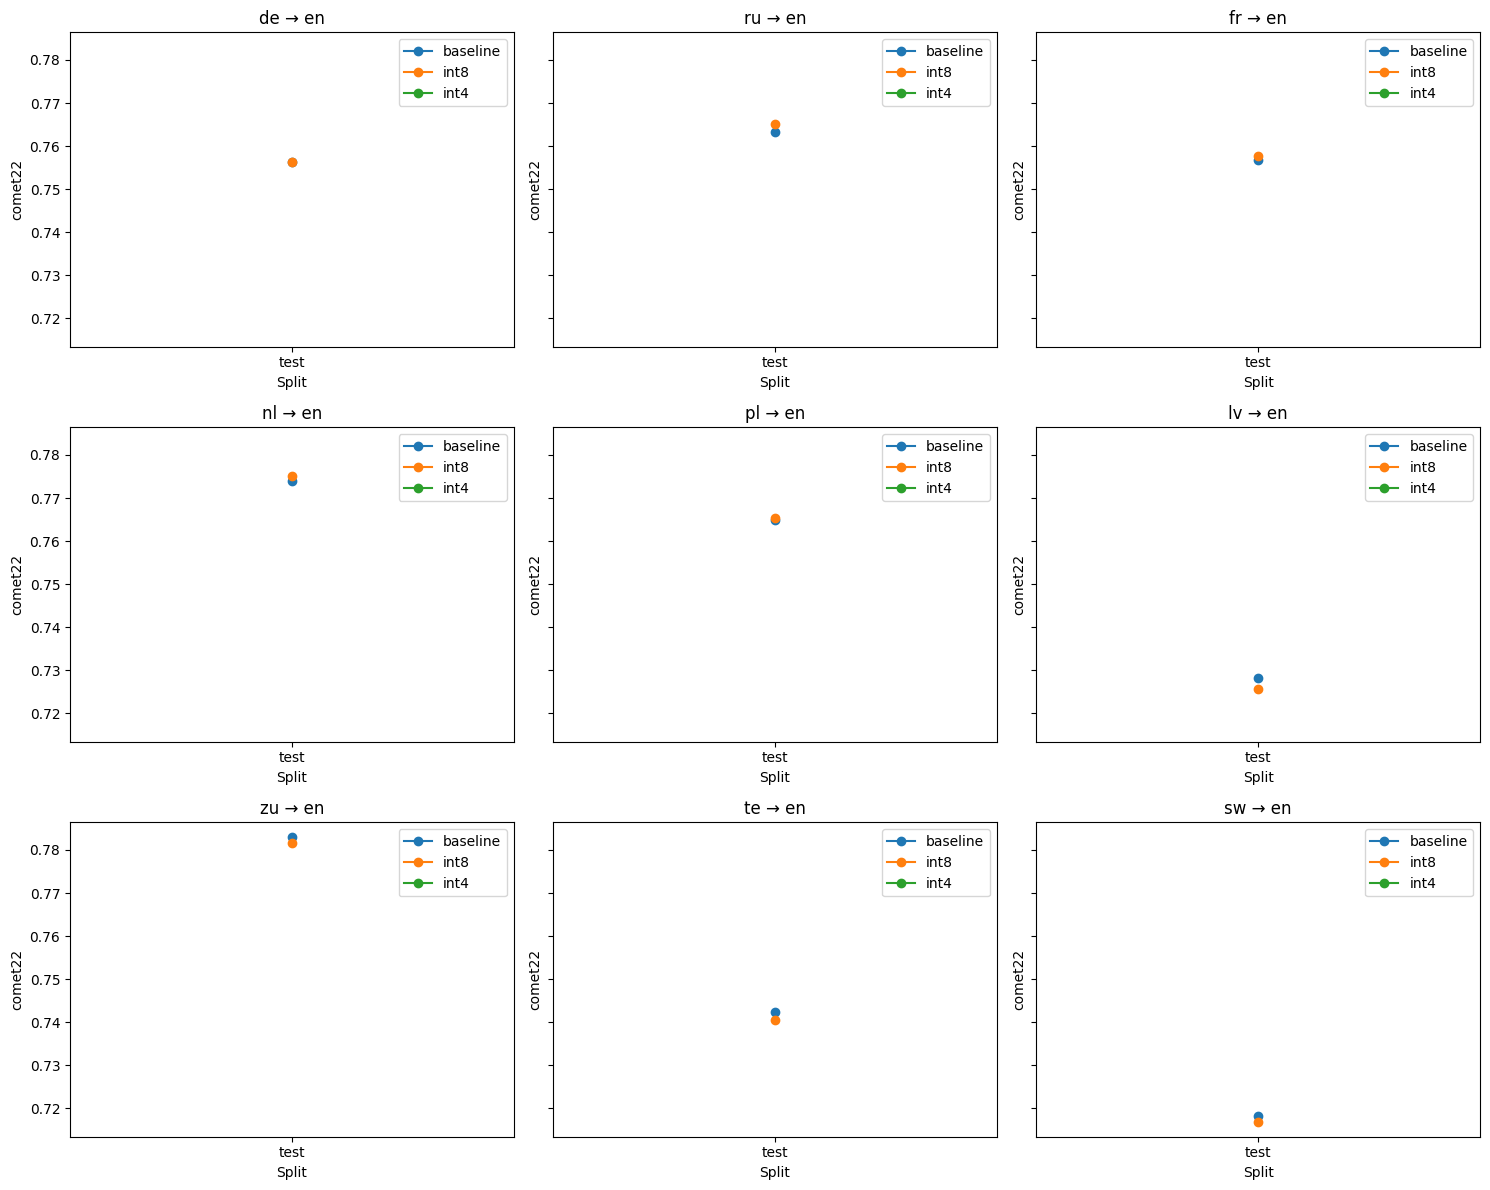

In [9]:
# Filter for en2x direction
en2x_df = all_df[all_df["direction"] == "en2x"]
# en2x_df = all_df[all_df["direction"] == "x2en"]

# Get unique languages
langs = en2x_df["lang"].unique()
n_langs = len(langs)

# Make subplots (1 row, multiple columns or in a grid)
fig, axes = plt.subplots(
    nrows=(n_langs + 2) // 3,  # up to 3 per row
    ncols=3,
    figsize=(15, 4 * ((n_langs + 2) // 3)),
    sharey=True
)
axes = axes.flatten()

for i, lang in enumerate(langs):
    ax = axes[i]
    subset = en2x_df[en2x_df["lang"] == lang]
    for sys in subset["system"].unique():
        sys_data = subset[subset["system"] == sys]
        ax.plot(
            sys_data["split"],
            sys_data["comet22"],
            marker="o",
            label=sys
        )
    ax.set_title(f"{lang} → en")
    ax.set_xlabel("Split")
    # ax.set_ylabel("chrF")
    ax.set_ylabel("comet22")
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


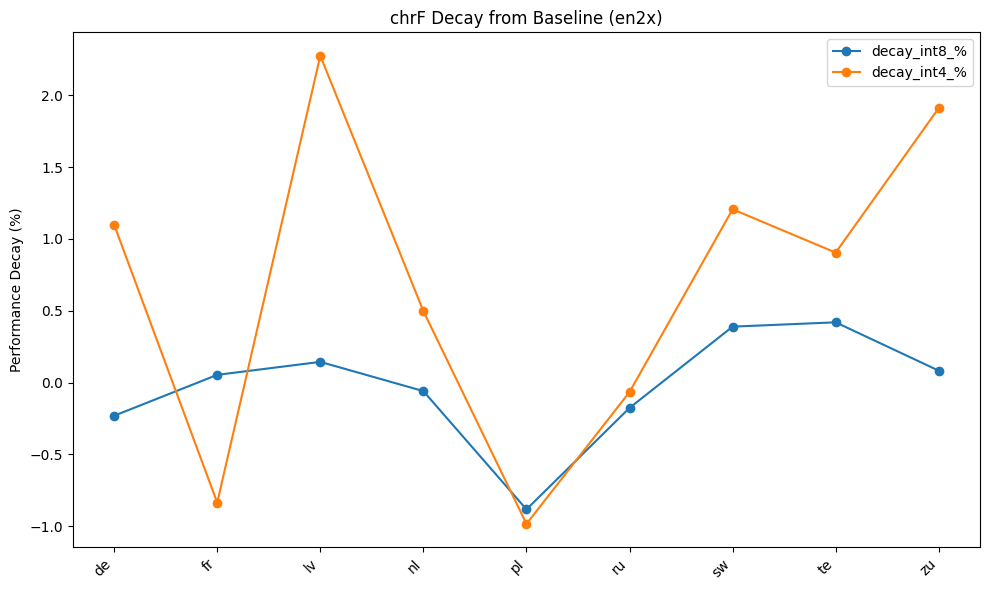

system,lang,split,decay_int8_%,decay_int4_%
0,de,test,-0.231348,1.098901
1,fr,test,0.053371,-0.836150
2,lv,test,0.143713,2.275449
3,nl,test,-0.059713,0.497611
4,pl,test,-0.883392,-0.984351
5,ru,test,-0.176600,-0.066225
6,sw,test,0.389105,1.206226
7,te,test,0.419241,0.904678
8,zu,test,0.082386,1.911353


In [5]:
# Filter en2x only
en2x_df = all_df[all_df["direction"] == "en2x"]

# Pivot so that we get one row per (lang, split), columns = system
pivot_df = en2x_df.pivot_table(
    index=["lang", "split"],
    columns="system",
    values="chrf"
).reset_index()

# Compute percentage decay
pivot_df["decay_int8_%"] = 100 * (pivot_df["baseline"] - pivot_df["int8"]) / pivot_df["baseline"]
pivot_df["decay_int4_%"] = 100 * (pivot_df["baseline"] - pivot_df["int4"]) / pivot_df["baseline"]

# Plot decay for each language
plt.figure(figsize=(10, 6))
for col in ["decay_int8_%", "decay_int4_%"]:
    plt.plot(
        pivot_df["lang"],
        pivot_df[col],
        marker="o",
        label=col
    )

plt.ylabel("Performance Decay (%)")
plt.title("chrF Decay from Baseline (en2x)")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Show dataframe
pivot_df_display = pivot_df[["lang", "split", "decay_int8_%", "decay_int4_%"]]
pivot_df_display
